In [11]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import xarray as xr

from pathlib import Path

# グラフの色指定
colors = ["tab:blue", "tab:orange", "tab:green", "tab:red", "tab:purple", "tab:brown", "tab:pink", "tab:gray", "tab:olive", "tab:cyan"]

# グラフ全体のフォント設定
plt.rcParams['font.family'] = 'serif'  # 全体のフォントをSerifに設定
plt.rcParams['mathtext.fontset'] = 'cm'  # 数式のフォントをComputer Modernに設定
plt.rcParams['mathtext.rm'] = 'serif'  # TeXの通常フォントをSerifに設定
plt.rcParams['font.size'] = 18  # デフォルトフォントサイズ
plt.rcParams['axes.labelsize'] = 18  # 軸ラベルのフォントサイズ
plt.rcParams['axes.titlesize'] = 22  # タイトルのフォントサイズ
plt.rcParams['legend.fontsize'] = 16  # 凡例のフォントサイズ
plt.rcParams['grid.color'] = 'gray'  # グリッドの色を薄い灰色に設定
plt.rcParams['grid.linestyle'] = ':'  # グリッドを点線に設定
plt.rcParams['grid.linewidth'] = 0.5  # グリッドの線幅を設定

In [12]:
network_type = "ER"
N = 20000
z = 6
cMin = 2.0
file_type = "final"
ini_type = "nonbfs"
index_cols = [] if file_type == "final" else ["time"]
index_cols.extend(["itr", "lambda", "mu", "rho", "c"])

sim_path = os.path.abspath(
        os.path.join(
            '..',
            f'java-project/output/sis/{network_type}/z={z}/N={N}cMin={cMin:.2f}{file_type}{ini_type}'
        )
    )
sim_results=[]
print(sim_path)
for path in Path(sim_path).glob('**/results_*.csv'):
    sim_results.append(pd.read_csv(path))
sim_results = pd.concat(sim_results)
display(sim_results)
sim_results = xr.Dataset.from_dataframe(
    sim_results.set_index(index_cols)
)
I=sim_results["I"]

/Users/penguin/trend-sar/java-project/output/sis/ER/z=6/N=20000cMin=2.00finalnonbfs


,itr,lambda,mu,rho,c,time,S,I
0,180,0.24,1.0,0.001,2.0,2000.0000,1841,18159
1,181,0.24,1.0,0.001,2.0,2000.0000,1934,18066
2,182,0.24,1.0,0.001,2.0,2000.0000,1853,18147
3,183,0.24,1.0,0.001,2.0,2000.0000,1942,18058
4,184,0.24,1.0,0.001,2.0,2000.0000,1849,18151
...,...,...,...,...,...,...,...,...
6055,95,0.00,1.0,1.000,2.0,31.9373,20000,0
6056,96,0.00,1.0,1.000,2.0,34.2772,20000,0
6057,97,0.00,1.0,1.000,2.0,35.3116,20000,0
6058,98,0.00,1.0,1.000,2.0,30.9782,20000,0


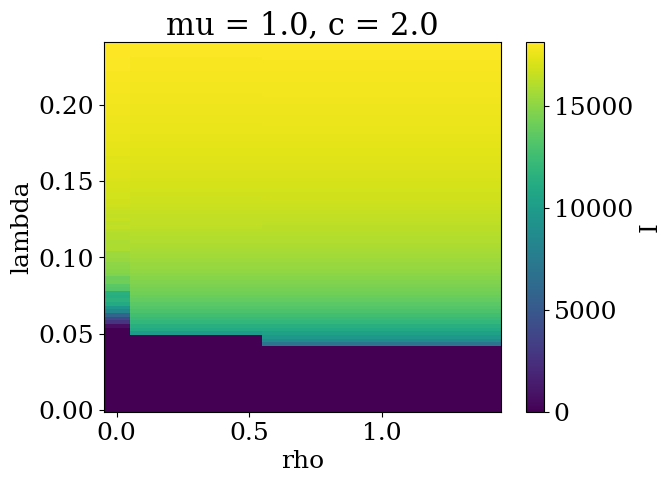

In [13]:
I.mean(dim="itr").plot()